<a href="https://colab.research.google.com/github/anushavk416/Datascience-Tasks/blob/main/youtube_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing and reading file
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("https://github.com/Taj1920/Data_Analysis/raw/refs/heads/main/Youtube_analysis/YOUTUBE%20CHANNELS%20DATASET.csv")

##EDA and Data cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ranking      100 non-null    float64
 1   Username     100 non-null    object 
 2   Subscribers  100 non-null    object 
 3   Uploads      100 non-null    object 
 4   Views        100 non-null    object 
 5   Country      94 non-null     object 
dtypes: float64(1), object(5)
memory usage: 4.9+ KB


In [ ]:
df.head()

,Ranking,Username,Subscribers,Uploads,Views,Country
0,1.0,MrBeast,336M,838,"66,853,633,536",US
1,2.0,T-Series,281M,"22,313","277,242,795,553",IN
2,3.0,Cocomelon-Nursery Rhymes,186M,1370,"194,361,752,276",US
3,4.0,Youtube Movies,185M,0,0,NaN
4,5.0,Set India,180M,"148,727","172,709,029,653",IN


In [ ]:
#checking nulls
df.isnull().sum()

,0
Ranking,1
Username,1
Subscribers,1
Uploads,1
Views,1
Country,7


In [ ]:
df['Country']

,Country
0,US
1,IN
2,US
3,NaN
4,IN
...,...
96,BR
97,US
98,IN
99,US


In [ ]:
#dropping last column as it consists of null in entire record
df = df.drop([100])

In [ ]:
df.shape

(100, 6)

In [ ]:
#handling rank column
df['Ranking'].unique()
df['Ranking'] = df['Ranking'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Ranking      100 non-null    int64 
 1   Username     100 non-null    object
 2   Subscribers  100 non-null    object
 3   Uploads      100 non-null    object
 4   Views        100 non-null    object
 5   Country      94 non-null     object
dtypes: int64(1), object(5)
memory usage: 4.8+ KB


In [ ]:
#handling username column
df['Username'].unique()
df['Username'] = df['Username'].str.strip()
df['Username'].unique()

array(['MrBeast', 'T-Series', 'Cocomelon-Nursery Rhymes',
       'Youtube Movies', 'Set India', 'Vlad & Niki', 'Kids Diana Show',
       'Like Nastya', 'Music', 'Zee Music Company', 'PewDiePie', 'WWE',
       'Stokes Twins', 'Goldmines', 'Sony SAB', 'Blackpink', 'ChuChu Tv',
       'Gaming', 'Zee TV', '5-Minute Crafts', 'BANGTANTY',
       'Baby Shark - Pinkfong Kids Song', 'Colors TV', 'HYBE LABELS',
       'Sports', 'Justin Bieber', 'KIMPRO', 'T-Series Bhakti Sagar',
       'UR.Cristiano', 'A4', 'Tips Official', 'Shemaroo Filmi Gaane',
       'Alan Chikin Chow', 'ZAMZAM ELECTRONIC TRADING', 'Aaj Tak',
       'Toys & Colors', 'Canal Kondzilla', 'El Reino Infantil',
       'Infobells-Hindi', 'Wave Music', 'EminemMusic', 'HAR PAL GEO',
       'MovieClips', 'Sony Music India', 'YRF', 'KL BRO Biju R ithvik',
       'Mark Rober', 'Dude Perfect', 'Taylor Swift', 'Fede Vigevani',
       'ARY Digital HD', 'LooLoo Kids', 'Billion Surprise Toys',
       'Marshmello', 'YOLO AVENTURAS', 'Shemaroo

In [ ]:
#handling subscribers column
df['Subscribers'].unique()
df[df['Subscribers'].str.endswith('M')]
df['Subscribers'] = df['Subscribers'].str.strip('M')
df['Subscribers'] = df['Subscribers'].astype(float)
df['Subscribers']


,Subscribers
0,336.0
1,281.0
2,186.0
3,185.0
4,180.0
...,...
95,46.0
96,46.0
97,45.6
98,45.5


In [ ]:
#handling uploads column
df['Uploads'].unique()
df['Uploads'] = df['Uploads'].str.replace(',', '')
df['Uploads'] = df['Uploads'].astype(int)
df['Uploads'].unique()

array([   838,  22313,   1370,      0, 148727,    796,   1282,    918,
        12787,   4800,  80964,    335,   9421,  94136,    603,    832,
       190672,   7391,   2674,   3399, 179052,   2253,    249,   3580,
        29140,     80,    971,   6859,   8988,   1413,  19224, 415087,
         1396,   3014,   1667,    731,  20481,    196, 152148,  41711,
         5941,   4333,   2873,    187,    463,    285,   1435, 155545,
          933,   1221,    508,   2655,  13166,   1143,   1158,    538,
          214,  11966,    142,   3468,   2072,   3688,   2009,   2909,
         2264,   1070, 234889,   6907, 111513,   9550,   3028,   1735,
         2915,    636,    157,    547,   4792,   4763,  24021,   1857,
          123,    362,   1921,   1193,   5310,   1334,   3201, 433181,
          916,    676,    314,    141,   1831,   1714,    170,  11880,
         1861])

In [ ]:
#handling views column
df['Views'].unique()
df['Views'] = df['Views'].str.replace(',', '')
df['Views'] = df['Views'].astype(int)
df['Views'].unique()

array([ 66853633536, 277242795553, 194361752276,            0,
       172709029653,  99291499729, 108987929584, 108128507997,
        72091345721,  29453929047,  90167179784,  16139307959,
        29936365183, 123172828384,  37502831600,  53265415943,
        97566987807,  27907581110,  24161704347,  47497893810,
        76490031656,  37279267924,  33636731466,  56715455039,
        37185631965,    721228815,  31487602900,  43171245557,
        30982452123,  48935762064,  34237265905,  35552274523,
        82391801354,  38923694296,  64042650819,  39661413683,
        43980109554,  32256297282,  64184880416,  64184220639,
        32518871280,  44702357371,  54385171265,   8956227211,
        18005895732,  37663171636,  17636583860,  59355707231,
        36603603223,  10602947691,  16389217605,  19763801820,
        25669598984,  25243008251,  20255686758,  33424121267,
        27575337685,   3237975581,  17599708994,  34460024944,
        19542079629,  33399550869,  43441258673,   6989

0 uploads and 0 views are still valid

In [ ]:
#handling country column
df[df['Country'].isnull()]
df.loc[[3, 8, 11, 17, 24], ['Country']] = 'WORLD'
df.loc[40, ['Country']] = 'US'
df['Country'].unique()

array(['US', 'IN', 'WORLD', 'JP', 'KR', 'CA', 'PT', 'AE', 'BR', 'AR',
       'PK', 'MX', 'IT', 'GB', 'RU', 'ES', 'ID', 'CL', 'PH', 'TR', 'PR',
       'SV', 'CO', 'NO'], dtype=object)

- **Youtube Movies:** worldwide
- **Music:** worldwide
- **WWE:** worldwide
- **Gaming:** worldwide
- **Sports:** worldwide
- **EminemMusic:** US

In [ ]:
# renaming subsribers
d = {'Subscribers':'Subscribers (in Millions)'}
df = df.rename(columns=d)
df.head()

,Ranking,Username,Subscribers (in Millions),Uploads,Views,Country
0,1,MrBeast,336.0,838,66853633536,US
1,2,T-Series,281.0,22313,277242795553,IN
2,3,Cocomelon-Nursery Rhymes,186.0,1370,194361752276,US
3,4,Youtube Movies,185.0,0,0,WORLD
4,5,Set India,180.0,148727,172709029653,IN


##EDA and data visualization

In [ ]:
df.head()

,Ranking,Username,Subscribers (in Millions),Uploads,Views,Country
0,1,MrBeast,336.0,838,66853633536,US
1,2,T-Series,281.0,22313,277242795553,IN
2,3,Cocomelon-Nursery Rhymes,186.0,1370,194361752276,US
3,4,Youtube Movies,185.0,0,0,WORLD
4,5,Set India,180.0,148727,172709029653,IN


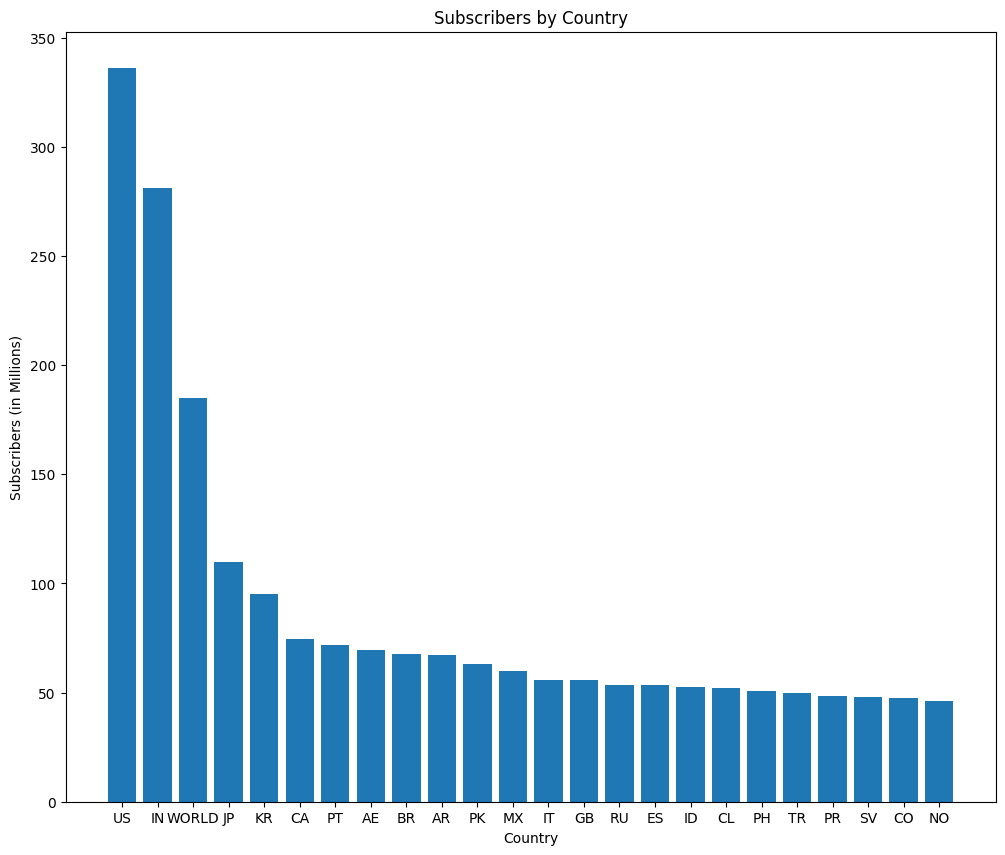

In [ ]:
#plotting Subscribers by Country
plt.figure(figsize = (12,10))

plt.bar(df['Country'], df['Subscribers (in Millions)'])
plt.xlabel('Country')
plt.ylabel('Subscribers (in Millions)')
plt.title('Subscribers by Country')
plt.show()

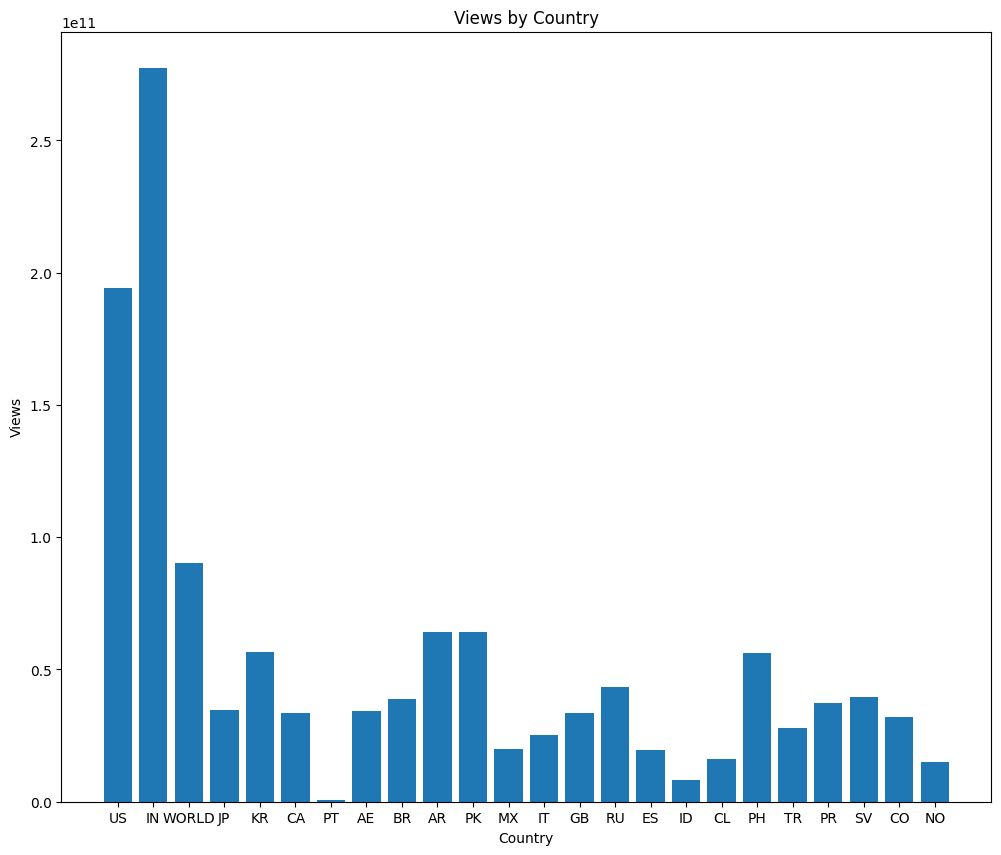

In [ ]:
# plotting Views by Country
plt.figure(figsize = (12,10))

plt.bar(df['Country'], df['Views'])
plt.xlabel('Country')
plt.ylabel('Views')
plt.title('Views by Country')
plt.show()

In [ ]:
#checking subscribers based on country
cat = df.groupby('Country')['Subscribers (in Millions)'].sum()
cat = pd.DataFrame(cat)
cat = cat.reset_index()
cat

,Country,Subscribers (in Millions)
0,AE,164.0
1,AR,123.0
2,BR,256.7
3,CA,74.4
4,CL,51.9
5,CO,47.3
6,ES,53.4
7,GB,55.6
8,ID,100.3
9,IN,2175.6


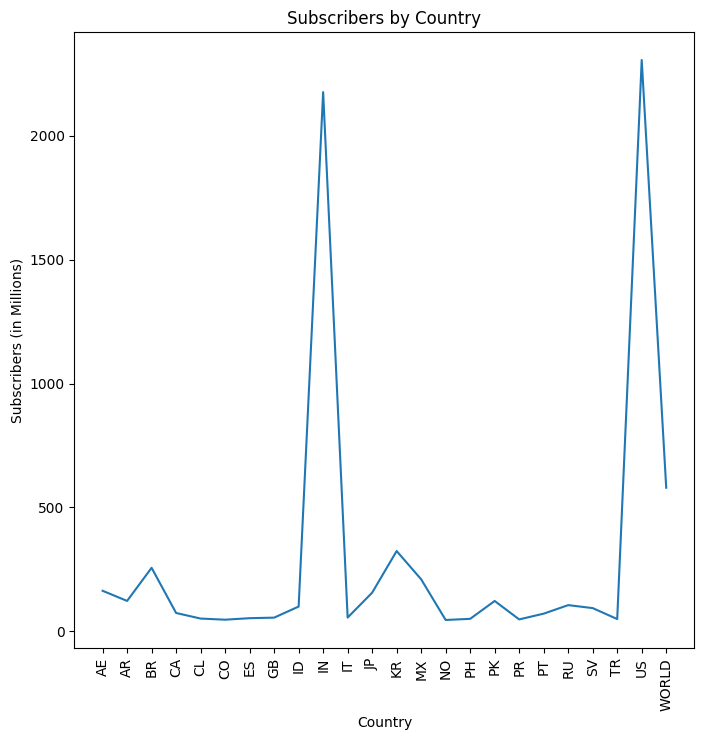

In [ ]:
#plotting subscribers based on country
plt.figure(figsize = (8,8))
plt.plot(cat['Country'], cat['Subscribers (in Millions)'])
plt.xlabel('Country')
plt.ylabel('Subscribers (in Millions)')
plt.title('Subscribers by Country')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
#checking views based on country
cat = df.groupby('Country')['Views'].sum()
cat = pd.DataFrame(cat)
cat = cat.reset_index()
cat

,Country,Views
0,AE,92543588510
1,AR,84298337577
2,BR,125316121608
3,CA,33636731466
4,CL,16190511067
5,CO,31911521616
6,ES,19542079629
7,GB,33424121267
8,ID,15179100418
9,IN,1566694146882


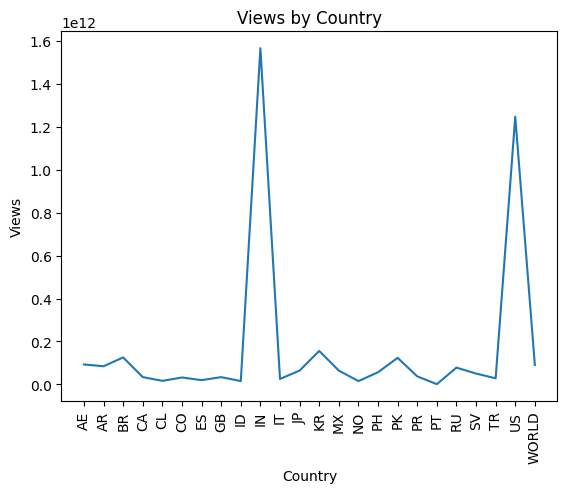

In [ ]:
#plotting views based on country
# plt.figure(figsize = (8,8))
plt.plot(cat['Country'], cat['Views'])
plt.xlabel('Country')
plt.ylabel('Views')
plt.title('Views by Country')
plt.xticks(rotation = 90)
plt.show()

Observation:
- US channels have more subscribers
- Viewership is higher in india


In [ ]:
df.head()

,Ranking,Username,Subscribers (in Millions),Uploads,Views,Country
0,1,MrBeast,336.0,838,66853633536,US
1,2,T-Series,281.0,22313,277242795553,IN
2,3,Cocomelon-Nursery Rhymes,186.0,1370,194361752276,US
3,4,Youtube Movies,185.0,0,0,WORLD
4,5,Set India,180.0,148727,172709029653,IN


In [ ]:
df['View rate'] = df['Views'] / df['Uploads']
df.head()

,Ranking,Username,Subscribers (in Millions),Uploads,Views,Country,View rate
0,1,MrBeast,336.0,838,66853633536,US,7.977761e+07
1,2,T-Series,281.0,22313,277242795553,IN,1.242517e+07
2,3,Cocomelon-Nursery Rhymes,186.0,1370,194361752276,US,1.418699e+08
3,4,Youtube Movies,185.0,0,0,WORLD,NaN
4,5,Set India,180.0,148727,172709029653,IN,1.161249e+06
